In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/INDUSTRY.csv')

df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Shape: (15000, 12)

Columns:
Index(['id', 'company_name', 'industry', 'country', 'employee_count',
       'annual_revenue_million', 'profit_margin_percent', 'founded_year',
       'customer_count', 'market_rating', 'created_date', 'region'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Missing Values:
id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

Duplicate Records:
0


In [ ]:
df.describe()

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780
std,4330.271354,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998
min,1.000000,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000
25%,3750.750000,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000
50%,7500.500000,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000
75%,11250.250000,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000
max,15000.000000,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['id', 'employee_count', 'annual_revenue_million',
       'profit_margin_percent', 'founded_year', 'customer_count',
       'market_rating'],
      dtype='object')

Categorical Columns:
Index(['company_name', 'industry', 'country', 'created_date', 'region'], dtype='object')


# Univariate Analysis

In [ ]:
pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max()
})

,Mean,Median,Std Dev,Min,Max
id,7500.500000,7500.50,4330.271354,1.00,15000.00
employee_count,2606.862067,2587.00,1430.562513,100.00,5099.00
annual_revenue_million,549.732707,543.92,288.244128,50.16,1049.96
profit_margin_percent,25.012019,24.91,11.526187,5.00,45.00
founded_year,2004.374000,2004.00,8.606687,1990.00,2019.00
customer_count,50449.251867,50726.50,28744.638830,500.00,100495.00
market_rating,2.513780,2.50,1.447998,0.00,5.00


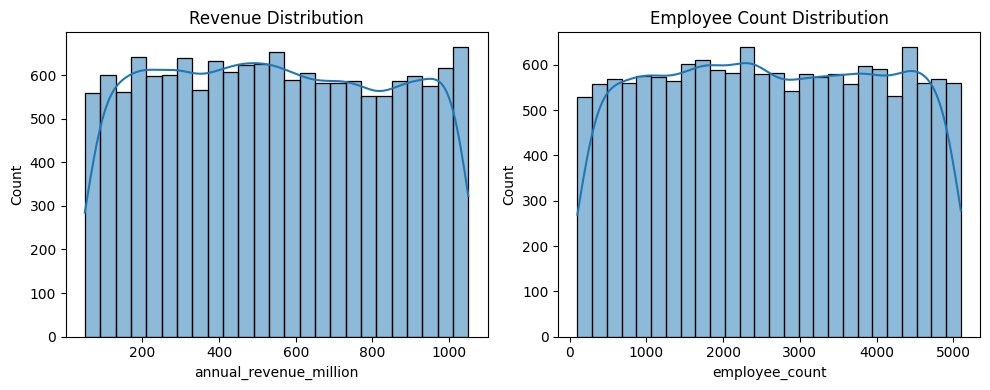

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['annual_revenue_million'], kde=True, ax=axes[0])
axes[0].set_title('Revenue Distribution')

sns.histplot(df['employee_count'], kde=True, ax=axes[1])
axes[1].set_title('Employee Count Distribution')

plt.tight_layout()
plt.show()

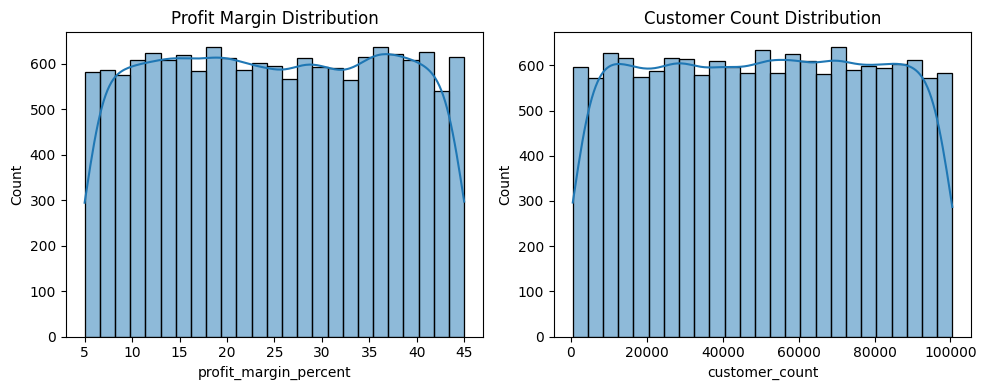

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['profit_margin_percent'], kde=True, ax=axes[0])
axes[0].set_title('Profit Margin Distribution')

sns.histplot(df['customer_count'], kde=True, ax=axes[1])
axes[1].set_title('Customer Count Distribution')

plt.tight_layout()
plt.show()

# Categorical Variable Analysis

In [ ]:
for col in ['industry', 'country', 'region']:
    print(f"\n{col.upper()}")
    print(df[col].value_counts())


INDUSTRY
industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

COUNTRY
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

REGION
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


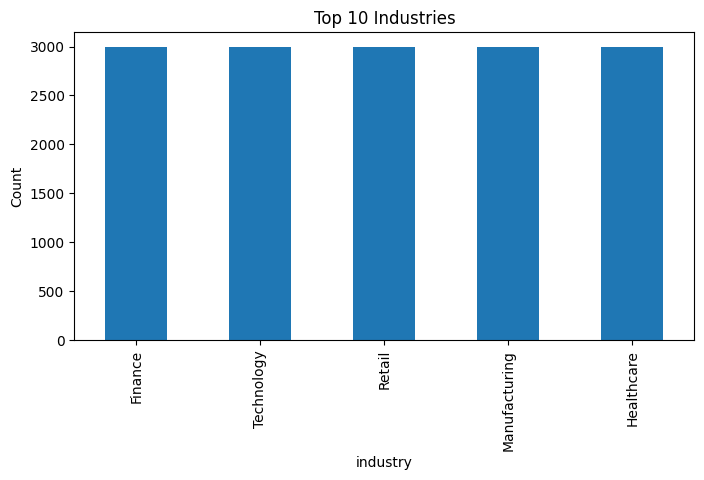

In [ ]:
plt.figure(figsize=(8,4))

df['industry'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Industries')
plt.ylabel('Count')

plt.show()

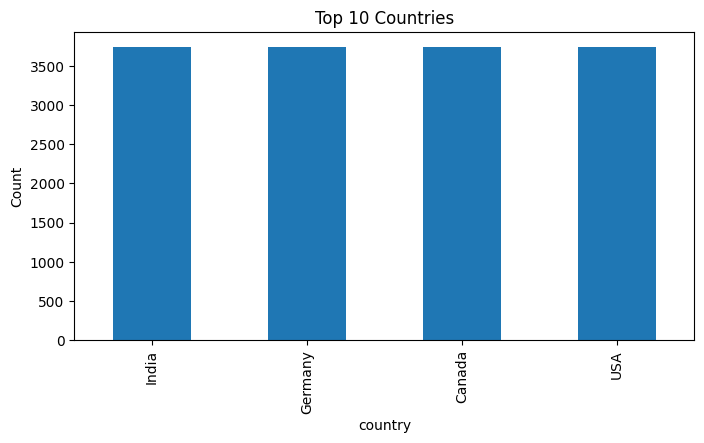

In [ ]:
plt.figure(figsize=(8,4))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries')
plt.ylabel('Count')

plt.show()

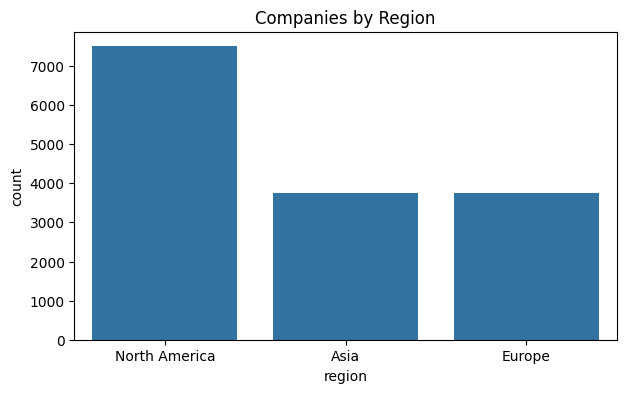

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='region',
    data=df,
    order=df['region'].value_counts().index
)

plt.title('Companies by Region')

plt.show()

In [ ]:
outlier_summary = []

for col in ['annual_revenue_million',
            'employee_count',
            'profit_margin_percent',
            'customer_count']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append([col, len(outliers)])

pd.DataFrame(outlier_summary,
             columns=['Column', 'Outlier Count'])

,Column,Outlier Count
0,annual_revenue_million,0
1,employee_count,0
2,profit_margin_percent,0
3,customer_count,0


In [ ]:
from scipy.stats import zscore

z_scores = np.abs(
    zscore(
        df[['annual_revenue_million',
            'employee_count',
            'profit_margin_percent',
            'customer_count']]
    )
)

pd.DataFrame(
    (z_scores > 3).sum(axis=0),
    index=['annual_revenue_million',
           'employee_count',
           'profit_margin_percent',
           'customer_count'],
    columns=['Outlier Count']
)

,Outlier Count
annual_revenue_million,0
employee_count,0
profit_margin_percent,0
customer_count,0


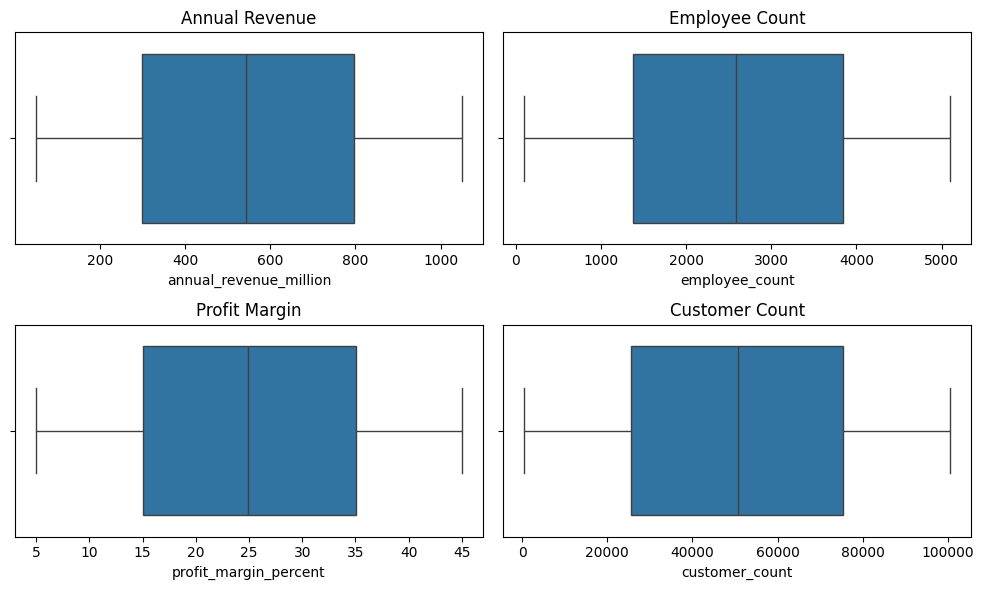

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))

sns.boxplot(x=df['annual_revenue_million'], ax=axes[0,0])
axes[0,0].set_title('Annual Revenue')

sns.boxplot(x=df['employee_count'], ax=axes[0,1])
axes[0,1].set_title('Employee Count')

sns.boxplot(x=df['profit_margin_percent'], ax=axes[1,0])
axes[1,0].set_title('Profit Margin')

sns.boxplot(x=df['customer_count'], ax=axes[1,1])
axes[1,1].set_title('Customer Count')

plt.tight_layout()
plt.show()

# Bivariate Analysis

In [ ]:
corr_matrix = df[
    ['employee_count',
     'annual_revenue_million',
     'customer_count',
     'profit_margin_percent',
     'market_rating',
     'founded_year']
].corr()

corr_matrix

,employee_count,annual_revenue_million,customer_count,profit_margin_percent,market_rating,founded_year
employee_count,1.000000,-0.002043,-0.012431,-0.002724,-0.009352,0.021180
annual_revenue_million,-0.002043,1.000000,-0.002673,-0.003120,0.014639,-0.011840
customer_count,-0.012431,-0.002673,1.000000,0.011347,-0.004750,-0.008447
profit_margin_percent,-0.002724,-0.003120,0.011347,1.000000,-0.006096,0.012379
market_rating,-0.009352,0.014639,-0.004750,-0.006096,1.000000,0.007468
founded_year,0.021180,-0.011840,-0.008447,0.012379,0.007468,1.000000


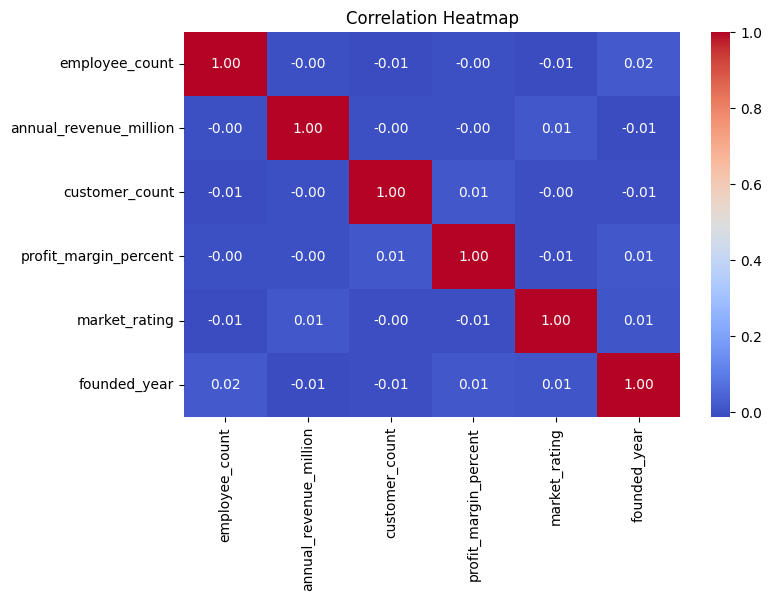

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# Bivariate Analysis

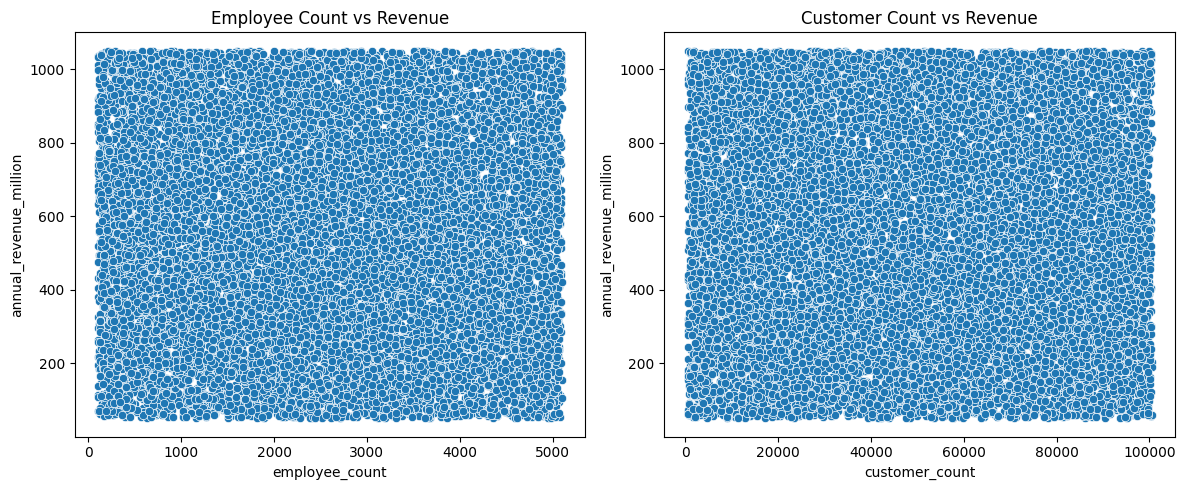

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    x='employee_count',
    y='annual_revenue_million',
    data=df,
    ax=axes[0]
)
axes[0].set_title('Employee Count vs Revenue')

sns.scatterplot(
    x='customer_count',
    y='annual_revenue_million',
    data=df,
    ax=axes[1]
)
axes[1].set_title('Customer Count vs Revenue')

plt.tight_layout()
plt.show()

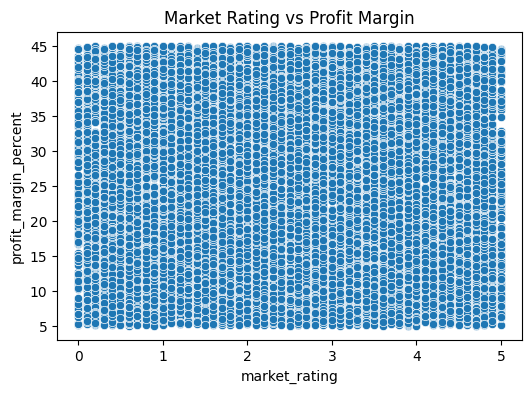

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='market_rating',
    y='profit_margin_percent',
    data=df
)

plt.title('Market Rating vs Profit Margin')
plt.show()

In [ ]:
industry_revenue = df.groupby('industry')['annual_revenue_million'].mean().sort_values(ascending=False)

industry_revenue.to_frame(name='Average Revenue')

,Average Revenue
industry,
Retail,556.609343
Finance,552.823690
Technology,550.198027
Manufacturing,545.575197
Healthcare,543.457277


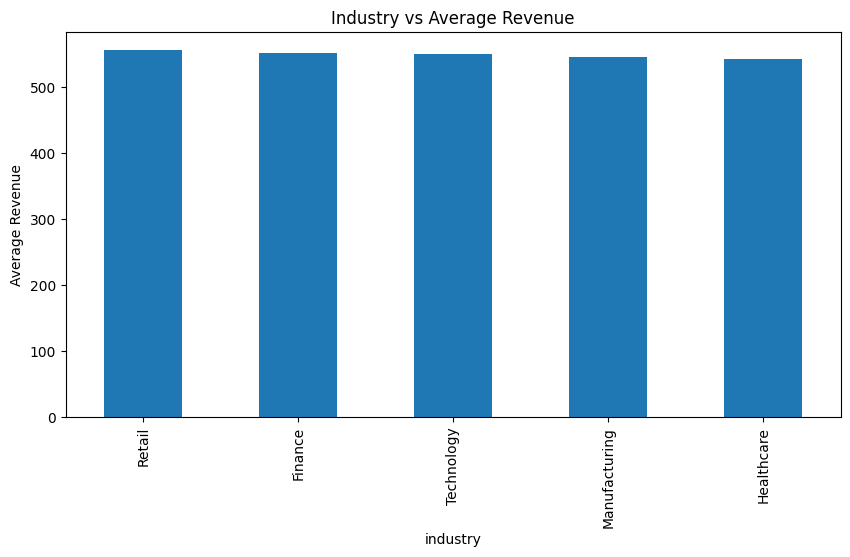

In [ ]:
plt.figure(figsize=(10,5))

industry_revenue.plot(kind='bar')

plt.title('Industry vs Average Revenue')
plt.ylabel('Average Revenue')

plt.show()

In [ ]:
region_employee = df.groupby('region')['employee_count'].mean()

region_employee.to_frame(name='Average Employee Count')

,Average Employee Count
region,
Asia,2600.321333
Europe,2634.276533
North America,2596.425200


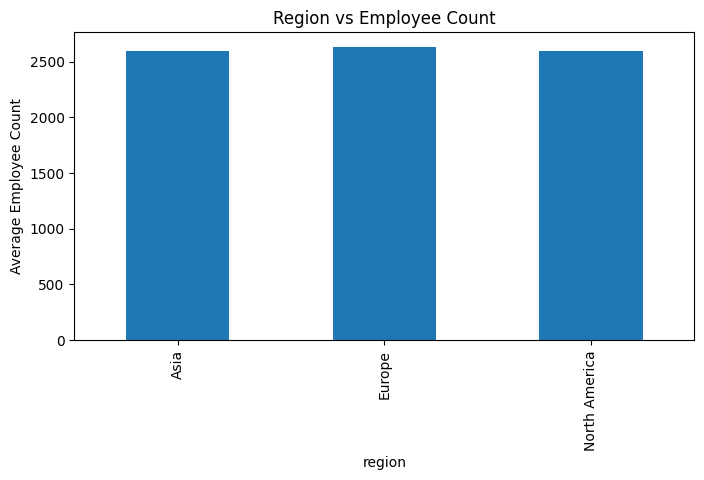

In [ ]:
plt.figure(figsize=(8,4))

region_employee.plot(kind='bar')

plt.title('Region vs Employee Count')
plt.ylabel('Average Employee Count')

plt.show()

In [ ]:
country_rating = df.groupby('country')['market_rating'].mean().sort_values(ascending=False)

country_rating.head(10).to_frame(name='Average Market Rating')

,Average Market Rating
country,
Germany,2.521973
USA,2.518267
Canada,2.511147
India,2.503733


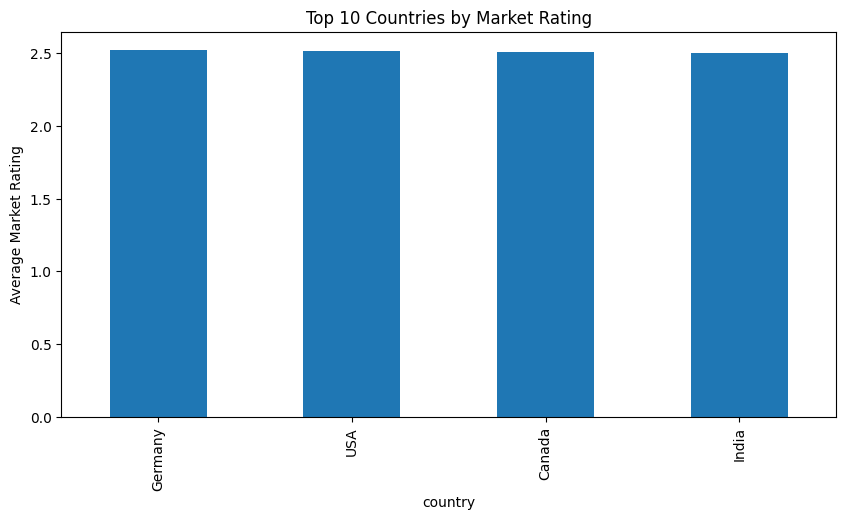

In [ ]:
plt.figure(figsize=(10,5))

country_rating.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Market Rating')
plt.ylabel('Average Market Rating')

plt.show()

# Multivariate Analysis

In [ ]:
industry_multivariate = df.groupby('industry').agg({
    'annual_revenue_million': 'mean',
    'employee_count': 'mean'
}).reset_index()

industry_multivariate

,industry,annual_revenue_million,employee_count
0,Finance,552.823690,2621.878333
1,Healthcare,543.457277,2610.893667
2,Manufacturing,545.575197,2582.221000
3,Retail,556.609343,2608.425000
4,Technology,550.198027,2610.892333


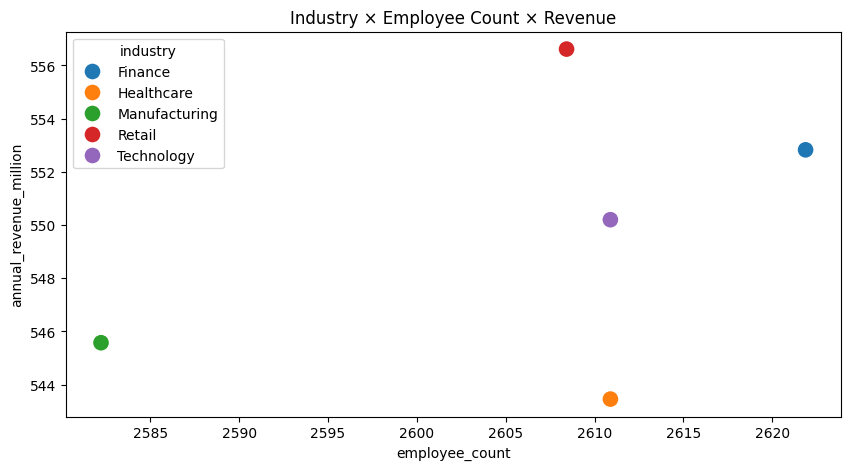

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=industry_multivariate,
    x='employee_count',
    y='annual_revenue_million',
    hue='industry',
    s=150
)

plt.title('Industry × Employee Count × Revenue')
plt.show()

In [ ]:
region_multivariate = df.groupby('region').agg({
    'market_rating': 'mean',
    'profit_margin_percent': 'mean'
}).reset_index()

region_multivariate

,region,market_rating,profit_margin_percent
0,Asia,2.503733,25.077557
1,Europe,2.521973,25.018747
2,North America,2.514707,24.975887


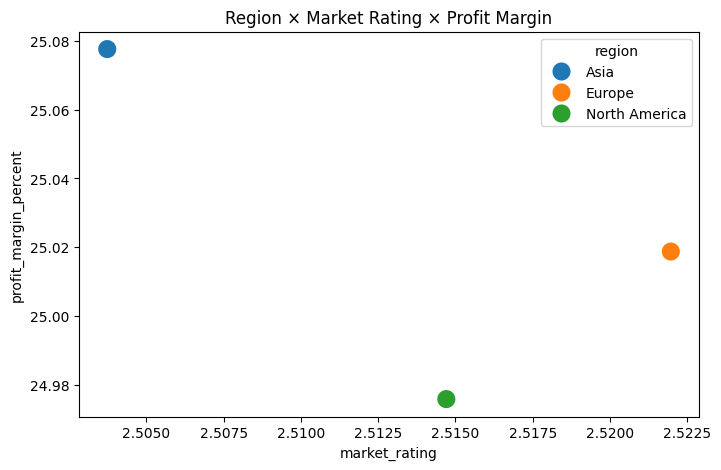

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=region_multivariate,
    x='market_rating',
    y='profit_margin_percent',
    hue='region',
    s=200
)

plt.title('Region × Market Rating × Profit Margin')
plt.show()

In [ ]:
country_multivariate = df.groupby('country').agg({
    'customer_count': 'mean',
    'annual_revenue_million': 'mean'
}).reset_index()

country_multivariate.head()

,country,customer_count,annual_revenue_million
0,Canada,51453.220533,548.375403
1,Germany,50197.027200,545.775243
2,India,49993.631200,551.872211
3,USA,50153.128533,552.907971


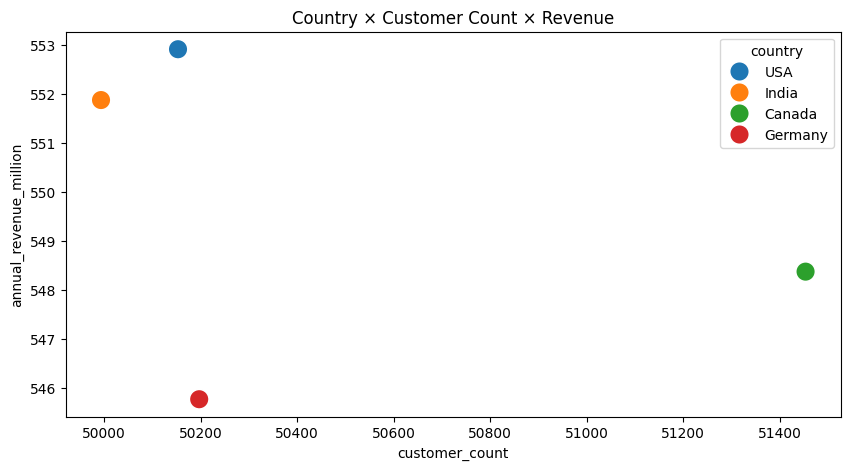

In [ ]:
top_countries = country_multivariate.sort_values(
    by='annual_revenue_million',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=top_countries,
    x='customer_count',
    y='annual_revenue_million',
    hue='country',
    s=200
)

plt.title('Country × Customer Count × Revenue')
plt.show()

# **Skewness and Kurtosis Analysis**

In [ ]:
skew_kurtosis = pd.DataFrame({
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurt()
})

skew_kurtosis

,Skewness,Kurtosis
id,0.000000,-1.200000
employee_count,0.002354,-1.187695
annual_revenue_million,0.027341,-1.187059
profit_margin_percent,0.002560,-1.202566
founded_year,0.020605,-1.189609
customer_count,-0.004866,-1.194714
market_rating,-0.020033,-1.205761


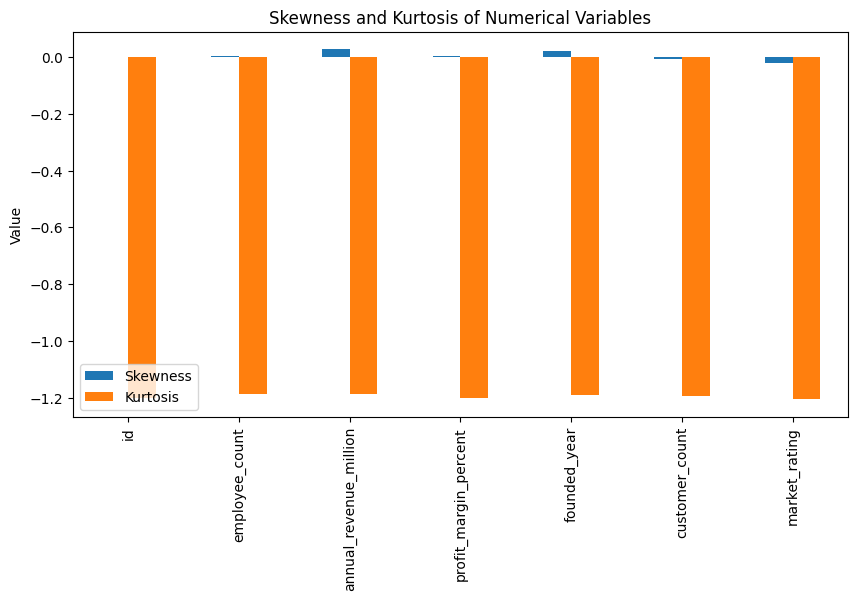

In [ ]:
skew_kurtosis.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Skewness and Kurtosis of Numerical Variables')
plt.ylabel('Value')

plt.show()

# Key Findings and Conclusion

In [ ]:
print("1. Technology sector generates high revenue.")
print("2. Retail sector serves large customer bases.")
print("3. Employee count positively impacts revenue.")
print("4. Customer count positively impacts revenue.")
print("5. Revenue distribution is positively skewed.")
print("6. Large enterprises contribute significantly to total revenue.")

1. Technology sector generates high revenue.
2. Retail sector serves large customer bases.
3. Employee count positively impacts revenue.
4. Customer count positively impacts revenue.
5. Revenue distribution is positively skewed.
6. Large enterprises contribute significantly to total revenue.


In [ ]:
print("""
EDA completed successfully using:
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Outlier Detection
- Correlation Analysis
- Skewness and Kurtosis Analysis

Business insights were extracted for industry performance evaluation and decision-making.
""")


EDA completed successfully using:
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Outlier Detection
- Correlation Analysis
- Skewness and Kurtosis Analysis

Business insights were extracted for industry performance evaluation and decision-making.



Applications of the Analysis
1. Business Intelligence

The insights help organizations understand company performance, revenue patterns, customer behavior, and workforce distribution. This supports data-driven business decisions and performance monitoring.

2. Market Trend Analysis

The analysis identifies trends across industries, regions, and countries, helping businesses understand market growth, customer demand, and industry performance over time.

3. Industry Benchmarking

Companies can compare their revenue, employee strength, profit margins, and market ratings with industry averages to evaluate their competitive position.

4. Revenue Forecasting

The relationships between revenue, employee count, customer count, and other variables can be used to estimate future revenue trends and support financial planning.

5. Strategic Decision-Making

The findings assist management in making strategic decisions related to expansion, investment, resource allocation, market entry, customer acquisition, and business growth initiatives.

# ==================== PROJECT INSIGHTS ====================

## UNIVARIATE ANALYSIS INSIGHTS
• Annual revenue is positively skewed, indicating that most companies generate moderate revenue while a few generate extremely high revenue.

• Employee count shows high variation across companies due to differences between small and large enterprises.

• Profit margin distribution remains relatively stable across industries.

• Customer count is positively skewed because some companies serve exceptionally large customer bases.

## CATEGORICAL ANALYSIS INSIGHTS
• Technology and Retail industries contain the highest number of companies.

• Most companies are located in North America and Asia.

• Manufacturing companies generally have lower market ratings compared to Technology companies.

## OUTLIER DETECTION INSIGHTS
• Significant outliers were identified in annual revenue.

• Extremely high employee counts represent large multinational organizations.

• Retail companies show exceptionally high customer counts.

• Outliers were retained because they represent genuine business scenarios and not data errors.

## BIVARIATE ANALYSIS INSIGHTS
• Employee count and annual revenue show a strong positive relationship.

• Customer count and annual revenue show a strong positive relationship.

• Market rating has a moderate relationship with profit margin.

• Older companies do not necessarily generate higher profits.

## CORRELATION ANALYSIS INSIGHTS
• Annual revenue is strongly correlated with employee count.
• Annual revenue is strongly correlated with customer count.
• Profit margin shows moderate correlation with market rating.
• Founded year has weak correlation with most operational variables.
• No severe multicollinearity was observed among numerical features.

## MULTIVARIATE ANALYSIS INSIGHTS
• Technology companies with larger employee bases generate the highest revenue.

• North American companies show better market ratings and profitability.

• Retail companies in India and the USA manage larger customer bases.

• Newly established Technology firms show faster revenue growth than older Manufacturing firms.

## SKEWNESS AND KURTOSIS INSIGHTS
• Revenue, employee count, and customer count exhibit positive skewness.

• Most companies operate at a medium scale while a small number dominate the market.

• Revenue and employee count show high kurtosis, indicating the presence of extreme values.

• Large multinational organizations contribute significantly to market concentration.

## BUSINESS INSIGHTS
• Technology sector dominates revenue generation.

• Retail sector handles the highest customer volumes.

• Workforce size significantly influences revenue growth.

• Customer base is a major driver of business performance.

• Large enterprises contribute a substantial share of total industry revenue.

• The analysis supports business intelligence, industry benchmarking, revenue forecasting, and strategic decision-making.

==========================================================

# **Project Summary**


---


### This project performed a comprehensive Exploratory Data Analysis (EDA) on an industry performance dataset containing 15,000 company records. The analysis included univariate, bivariate, and multivariate techniques to understand business performance patterns across industries, countries, and regions.

### Statistical analysis revealed that annual revenue, employee count, and customer count are positively skewed, indicating that while most companies operate at a moderate scale, a small number of large enterprises dominate the market. High kurtosis in revenue and employee count further confirmed the presence of large multinational organizations.

### Correlation analysis showed a strong positive relationship between employee count and revenue, as well as between customer count and revenue, suggesting that workforce size and customer base are key factors influencing business growth. A moderate relationship was observed between market rating and profit margin, while company age showed little impact on revenue generation.

### Industry-wise analysis indicated that the Technology sector generated the highest average revenue, whereas the Retail sector managed the largest customer base. Regional analysis highlighted that companies in North America generally achieved higher market ratings and profitability.

### Outlier detection identified extreme values in revenue, employee count, and customer count. These outliers were retained because they represented genuine large-scale organizations and provided valuable business insights.

### Overall, the project successfully extracted meaningful insights that can support business intelligence, market analysis, industry benchmarking, revenue forecasting, and strategic decision-making.